In [1]:
import pandas as pd
import pymysql
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

* 한글 폰트 설정

In [2]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

### DB 연결

* pymysql 연결

In [3]:
conn = pymysql.connect(
    host='localhost',
    user='root',
    password='1221',
    database='LOL_data'
)

* sqlAlchemy(pymysql) 연결(이걸 사용 ㅎ)

In [4]:
host = 'localhost'
port = '3306'
user = 'root'
password = '1221'
database = 'LOL_data'

engine = create_engine(f"mysql+pymysql://{user}:{password}@{host}:{port}/{database}")

* 관련 함수

In [9]:
def assist_id_list2int(data): # assist ID의 리스트를 integer로 변환
    data = [1 if x in data else 0 for x in range(11)]
    return int(''.join(map(str, data)), 2)

def get_assist_id_list(data): # integer를 assist ID의 리스트로 변환
    data = ''.join(['0' for x in range(11 - len(bin(data)[2:]))]) + bin(data)[2:]
    return [i for i in range(len(data)) if data[i] == '1']

## 포탑 파괴 횟수

### 데이터 가져오기

* building_kill 테이블

In [11]:
query = "SELECT match_id, participant_id, assist_id, line_type, tower_type, timestamp div 60000 as ts FROM building_kill;"
bk = pd.read_sql(query, engine)

* game_end 테이블

In [13]:
query = 'select distinct match_id, timestamp div 60000 as ts from game_end;'
ge = pd.read_sql(query, engine)

* champion_dict 테이블

In [15]:
query = "SELECT * FROM champion_dict;"
cd = pd.read_sql(query, engine)

* champion_participant_id 테이블

In [17]:
query = "SELECT distinct * FROM champion_participant_id;"
cpi = pd.read_sql(query, engine)

### 데이터 전처리

In [17]:
bk['assist_id'] = bk['assist_id'].fillna(0)

In [19]:
bk['assist_id'] = bk['assist_id'].astype(int)
bk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 611278 entries, 0 to 611277
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   match_id        611278 non-null  int64 
 1   participant_id  611278 non-null  int64 
 2   assist_id       611278 non-null  int32 
 3   line_type       611278 non-null  object
 4   tower_type      611278 non-null  object
 5   ts              611278 non-null  int64 
dtypes: int32(1), int64(3), object(2)
memory usage: 25.7+ MB


In [21]:
bk['assist_id'] = bk['assist_id'].map(get_assist_id_list)
bk.head(3)

,match_id,participant_id,assist_id,line_type,tower_type,ts
0,7346623650,2,"[4, 5]",BOT_LANE,OUTER_TURRET,13
1,7346623650,4,"[2, 5]",MID_LANE,OUTER_TURRET,14
2,7346623650,2,"[4, 5]",BOT_LANE,OUTER_TURRET,13


In [23]:
bk['killer_id'] = bk.apply(lambda x: list(x['assist_id']) + list(str(x['participant_id'])), axis=1)

In [25]:
bk = bk.drop(['assist_id', 'participant_id'], axis=1).explode('killer_id')

In [27]:
bk.head(3)

,match_id,line_type,tower_type,ts,killer_id
0,7346623650,BOT_LANE,OUTER_TURRET,13,4
0,7346623650,BOT_LANE,OUTER_TURRET,13,5
0,7346623650,BOT_LANE,OUTER_TURRET,13,2


In [29]:
bk.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1272843 entries, 0 to 611277
Data columns (total 5 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   match_id    1272843 non-null  int64 
 1   line_type   1272843 non-null  object
 2   tower_type  1272843 non-null  object
 3   ts          1272843 non-null  int64 
 4   killer_id   1272843 non-null  object
dtypes: int64(2), object(3)
memory usage: 58.3+ MB


In [31]:
bk[['ts', 'killer_id']] = bk[['ts', 'killer_id']].astype('int8')

In [33]:
bk.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1272843 entries, 0 to 611277
Data columns (total 5 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   match_id    1272843 non-null  int64 
 1   line_type   1272843 non-null  object
 2   tower_type  1272843 non-null  object
 3   ts          1272843 non-null  int8  
 4   killer_id   1272843 non-null  int8  
dtypes: int64(1), int8(2), object(2)
memory usage: 41.3+ MB


### 챔프 별 게임 당 평균 포탑 파괴 횟수

In [35]:
bk = bk[bk['killer_id'] != 0]

In [37]:
bk_cnt = bk.groupby(['match_id', 'killer_id', 'ts']).size().reset_index().rename({0: 'count'}, axis=1)

In [41]:
bk_cnt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 794520 entries, 0 to 794519
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   match_id   794520 non-null  int64
 1   killer_id  794520 non-null  int8 
 2   ts         794520 non-null  int8 
 3   count      794520 non-null  int64
dtypes: int64(2), int8(2)
memory usage: 13.6 MB


In [43]:
ge['ts'] = ge['ts'].map(lambda x: [i for i in range(x+1)])

In [45]:
ge = ge.explode('ts')

In [47]:
ge['ts'] = ge['ts'].astype(int)

In [49]:
ge['killer_id'] = [[i for i in range(1, 11)]] * len(ge)

In [51]:
ge = ge.explode('killer_id')

In [63]:
ge[['ts', 'killer_id']] = ge[['ts', 'killer_id']].astype('int8')
ge.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15164540 entries, 0 to 59863
Data columns (total 3 columns):
 #   Column     Dtype
---  ------     -----
 0   match_id   int64
 1   ts         int8 
 2   killer_id  int8 
dtypes: int64(1), int8(2)
memory usage: 260.3 MB


In [107]:
bk_cnt_ts = ge.merge(bk_cnt, on=['match_id', 'ts', 'killer_id'], how='left').fillna(0)
bk_cnt_ts['count'] = bk_cnt_ts['count'].astype('int8')

In [108]:
bk_cnt_ts.duplicated().sum()

0

In [109]:
bk_cnt_ts = bk_cnt_ts\
            .merge(cpi.rename({'participant_id': 'killer_id'}, axis=1), on=['match_id', 'killer_id'], how='left')\
            .drop('killer_id', axis=1)

In [117]:
bk_cnt_ts['champion_id'] = bk_cnt_ts['champion_id'].astype('int16')
print(bk_cnt_ts.duplicated().sum())

0


In [118]:
bk_cnt_ts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15164540 entries, 0 to 15164539
Data columns (total 4 columns):
 #   Column       Dtype
---  ------       -----
 0   match_id     int64
 1   ts           int8 
 2   count        int8 
 3   champion_id  int16
dtypes: int16(1), int64(1), int8(2)
memory usage: 173.5 MB


In [131]:
bk_cnt_ts = bk_cnt_ts.groupby(['champion_id', 'ts'])['count'].mean().sort_index().reset_index().set_index('champion_id')

In [141]:
cd = cd.set_index('champion_name')

In [157]:
bk_cnt_ts.loc[cd.loc['애니', 'champion_id']]

,ts,count
champion_id,,
1,0,0.000000
1,1,0.000000
1,2,0.000000
1,3,0.000000
1,4,0.000000
1,5,0.000000
1,6,0.000000
1,7,0.000000
1,8,0.000000


Text(0, 0.5, 'mean of building_kill')

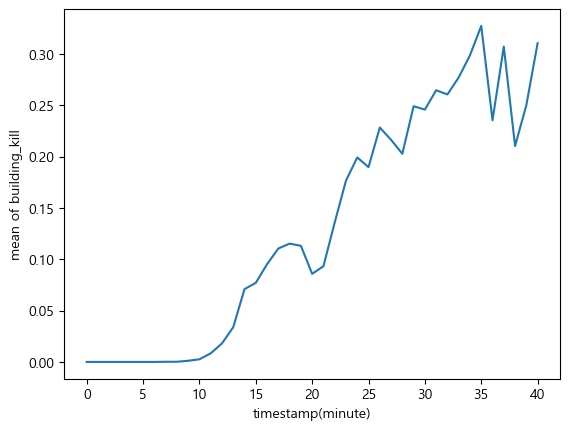

In [169]:
data = bk_cnt_ts.loc[cd.loc['갈리오', 'champion_id']]
data = data[data['ts'] <= 40]

plt.plot(data['ts'], data['count'])
plt.xlabel('timestamp(minute)')
plt.ylabel('mean of building_kill')

In [181]:
dashboard = cd.reset_index()\
            .set_index('champion_id')\
            .join(bk_cnt_ts, on='champion_id')\
            .set_index('champion_name')[['ts', 'count']]

In [189]:
dashboard.to_csv('building_kill_champ_per_min.csv', encoding='utf8')

### 포탑 골드 획득 횟수

In [22]:
query = '''with tpd_cnt as (
	select match_id, participant_id, count(*) as count
	from turret_plate_destroyed
	group by 1, 2
)
select cd.champion_name, avg(if(count is null, 0, count)) as mean_count
from (tpd_cnt tpd right join champion_participant_id cpi on tpd.match_id = cpi.match_id and tpd.participant_id = cpi.participant_id)
	join champion_dict cd on cpi.champion_id = cd.champion_id
group by 1
order by 2 desc;'''

In [24]:
turret_plate_destroyed_per_champ = pd.read_sql(query, engine)

<Axes: ylabel='champion_name'>

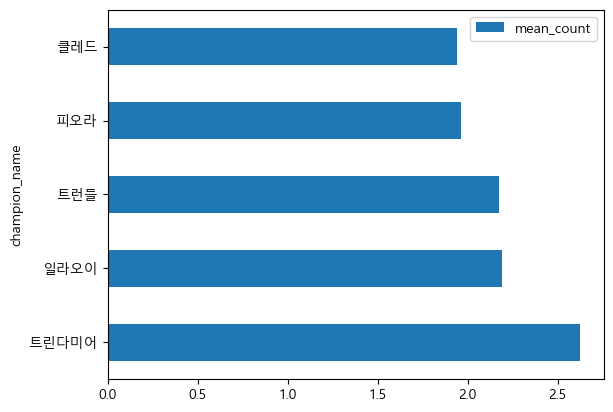

In [26]:
turret_plate_destroyed_per_champ.head(5).plot(kind='barh', x='champion_name')

In [30]:
turret_plate_destroyed_per_champ.to_csv('mean_turret_plate_destroyed_per_game.csv', encoding='utf8')